# CAFE + AU Spatial Alignment: Generalizable Facial Expression Recognition
### Full Training + Evaluation Notebook
Based on ECCV 2024 — Zhang et al. | Improved with Spatial AU Alignment

**Original CAFE Pipeline:**
```
Input image
  ├── CLIP (frozen) ──────────────────── image_features (512)
  └── ResNet-18 (trained) → sigmoid ──── mask
                                    ↓
                    image_features × sigmoid(x) = masked features
                                    ↓
              channel separation (7 groups) + channel diverse loss
                                    ↓
                    loss = l_cls + 1.5×l_sep + 5×l_div
```

**Our Improvement — AU Spatial Alignment:**
```
Input image
  ├── CLIP (frozen) ──────────────────── image_features (512)
  └── ResNet-18
        ├── layer4 spatial map (7×7) ──→ AU alignment loss  ← NEW
        └── GAP → sigmoid mask
                        ↓
          image_features × sigmoid(x) = masked features
                        ↓
        channel separation + channel diverse loss
                        ↓
    loss = l_cls + 1.5×l_sep + 5×l_div + 0.5×l_AU  ← NEW
```

**Key Idea:** The AU map is a spatial guidance template built from a fixed codebook
(expression → which AUs are active → which face regions matter). It tells the
ResNet-18 mask *where* on the face to pay attention, rather than letting it figure
that out from scratch. This improves generalization across domains.

## 1. Install Dependencies

In [ ]:
!pip install ftfy regex tqdm kagglehub
!pip install git+https://github.com/openai/CLIP.git
!pip install scipy  # needed for AU heatmap Gaussian smoothing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rp46xx_6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rp46xx_6
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=00ace63daf063c2589f0721558bd9909d865c09984d640ff511d9ece26041985
  Stored in directory: /tmp/pip-ephem-wheel-cache-q0qv04_o/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Your Drive folder path ───────────────────────────────────────────
DRIVE_FOLDER = '/content/drive/MyDrive/deeplearning'


print('Files in your deeplearning folder:')
for f in os.listdir(DRIVE_FOLDER):
    print(' ', f)

Mounted at /content/drive
Files in your deeplearning folder:


## 3. Set File Paths from Drive

In [3]:
import os
import kagglehub

# ── ResNet-18 MS-Celeb weights (from Drive) ──────────────────────────
MSCELEB_PATH = os.path.join(DRIVE_FOLDER, 'resnet18_msceleb.pth')

# ── Copy kaggle.json from Drive ──────────────────────────────────────
!mkdir -p ~/.kaggle
!cp "{DRIVE_FOLDER}/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# ── Download dataset from Kaggle ─────────────────────────────────────

# RAF-DB
# dataset_path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

# FERPlus ___________________________________________________________________________________ UNCOMMENT for FERplus
# dataset_path = kagglehub.dataset_download("arnabkumarroy02/ferplus")

# affectnet
dataset_path = kagglehub.dataset_download("mstjebashazida/affectnet")

# MMA
# dataset_path = kagglehub.dataset_download("mahmoudima/mma-facial-expression")

# SFEW
# dataset_path = kagglehub.dataset_download("vlntnstarodub/datasetsfew")

# ────────────────────────────────────────────────────────────────────

print('MS-Celeb weights found :', os.path.exists(MSCELEB_PATH))
print('Dataset path           :', dataset_path)

# See what's inside
print('\nDataset contents:')
for f in os.listdir(dataset_path):
    print(' ', f)

cp: cannot stat '/content/drive/MyDrive/deeplearning/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


100%|██████████| 324M/324M [00:01<00:00, 180MB/s]

Extracting files...


MS-Celeb weights found : False
Dataset path           : /root/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1

Dataset contents:
  archive (3)


## 4. Explore Dataset Structure

In [4]:
import os

print('Dataset contents:')
for item in os.listdir(dataset_path):
    print(' ', item)

Dataset contents:
  archive (3)


In [5]:
import os

# Find actual structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    if level < 3:  # only show 3 levels deep
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

1/
  archive (3)/
    Train/
    Test/


Classes found: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


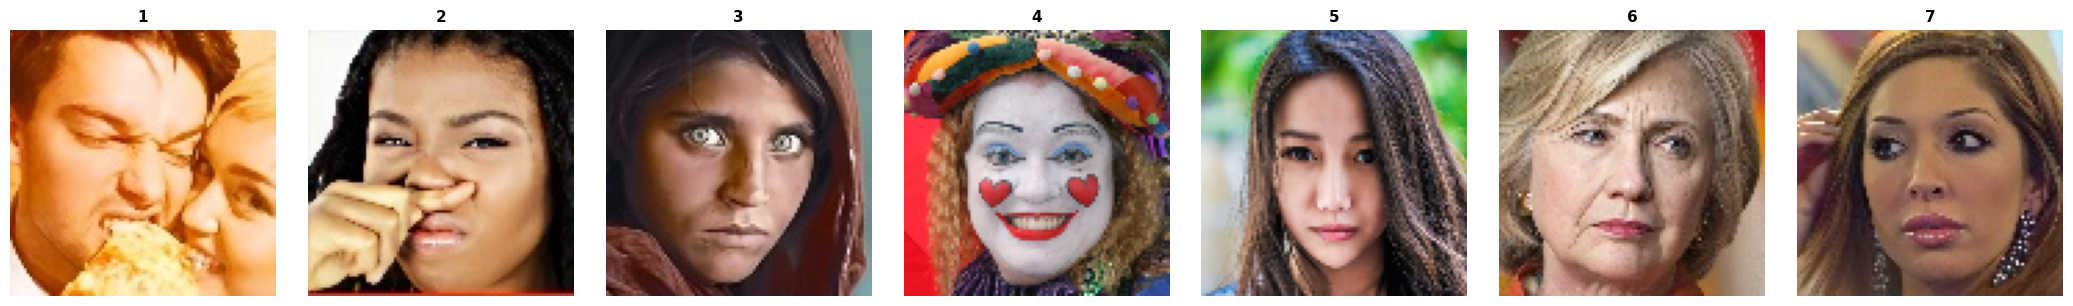

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# ── Adjust split name based on your dataset ──
# RAF-DB uses 'train' / 'test'
# FERPlus uses 'train' / 'test' / 'validation'

#RAF-DB
# train_dir = os.path.join(dataset_path,'DATASET', 'train')

#FERPlus
# train_dir = os.path.join(dataset_path,'train')    #___________________________________________________________________________________ UNCOMMENT for FERplus

#AffectNET
train_dir = os.path.join(dataset_path,'archive (3)', 'Train')    #___________________________________________________________________________________ UNCOMMENT for AffectNET

# MMA
# train_dir = os.path.join(dataset_path, 'MMAFEDB','train')    #___________________________________________________________________________________ UNCOMMENT for MMA

# SFEW
# train_dir = os.path.join(dataset_path, 'Train')    #___________________________________________________________________________________ UNCOMMENT for SFEW

classes = sorted([c for c in os.listdir(train_dir) if (c != 'contempt' and c != "Contempt")]) #exclude 'contempt' class for ferplus to make it 7 classes
print('Classes found:', classes)

# Sample images
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))

# handle case when only 1 class
if len(classes) == 1:
    axes = [axes]

for col, (idx, emotion) in enumerate(zip(range(1, len(classes)+1), classes)):
    emotion_path = os.path.join(train_dir, emotion)

    img_file = random.choice(os.listdir(emotion_path))
    img = Image.open(os.path.join(emotion_path, img_file))

    axes[col].imshow(img, cmap='gray')
    axes[col].axis('off')
    axes[col].set_title(f"{idx}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Imports

In [ ]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms
from torch.autograd import Variable
from torch.nn.modules.module import Module
from torch.nn.modules.utils import _pair
from torch.nn.parameter import Parameter

import clip
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load CLIP model (frozen)
clip_model, preprocess = clip.load("ViT-B/32", device=device)
print('CLIP loaded.')

Device: cuda:0
CLIP loaded.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# AU CODEBOOK + SPATIAL HEATMAP BUILDER  (Our Improvement)
# ══════════════════════════════════════════════════════════════════
#
# The AU codebook maps each expression → active AUs (from FACS literature).
# The AU map tells the ResNet-18 sigmoid mask WHERE to focus on the face.
#
# AU region mapping (normalized [0,1] coords on a 224×224 face crop):
#   AU1,2,4  → brow region    (y: 0.15–0.35)
#   AU5,6,7  → eye region     (y: 0.30–0.50)
#   AU9,10   → nose region    (y: 0.45–0.60)
#   AU12,13,14,15,16,17 → mouth/chin (y: 0.58–0.85)
#   AU20,23,24,25,26,27 → mouth wide/open (y: 0.55–0.85)
#
# The heatmap is 7×7 (matching ResNet-18 layer4 spatial size).
# It is used ONLY during training as a soft spatial guidance signal.

from scipy.ndimage import gaussian_filter

# Expression index order (matches FolderDataset sorted class order)
# sorted → ['angry','disgust','fear','happy','neutral','sad','surprise']
# But our CLASS_NAMES for RAF-DB are: surprise fear disgust happy sad angry neutral
# The actual index depends on alphabetical sort — we key by name below.

# AU codebook: expression name → list of active AUs
# Based on Ekman's FACS prototypical expressions
AU_CODEBOOK = {
    'angry':    [4, 5, 7, 23, 24],          # brow lower, lid raise, lip press
    'disgust':  [9, 15, 16, 25, 26],         # nose wrinkle, lip depress, mouth open
    'fear':     [1, 2, 4, 5, 7, 20, 26],     # brow raise, wide eyes, lip stretch
    'happy':    [6, 12],                      # cheek raise, lip corner pull
    'neutral':  [],                           # no specific AUs
    'sad':      [1, 4, 15, 17],              # inner brow raise, brow lower, lip depress, chin raise
    'surprise': [1, 2, 5, 26, 27],           # brow raise, wide eyes, mouth open
}

# AU → approximate spatial location on 7×7 grid (row, col) — center of region
# 7×7 grid covers 224×224 image, each cell = 32×32 px
AU_LOCATIONS = {
    # Brow AUs → row 1-2
    1:  [(1, 2), (1, 4)],   # inner brows (left + right)
    2:  [(1, 1), (1, 5)],   # outer brows
    4:  [(1, 2), (1, 4)],   # brow lowerer
    # Eye AUs → row 2
    5:  [(2, 2), (2, 4)],   # upper lid raiser
    6:  [(2, 1), (2, 5)],   # cheek raiser
    7:  [(2, 2), (2, 4)],   # lid tightener
    # Nose AUs → row 3
    9:  [(3, 3)],            # nose wrinkler
    10: [(3, 3)],
    # Mouth/lip AUs → row 4-5
    12: [(4, 2), (4, 4)],   # lip corner puller
    13: [(4, 2), (4, 4)],
    14: [(4, 2), (4, 4)],
    15: [(4, 2), (4, 4)],   # lip corner depressor
    16: [(4, 3)],
    17: [(5, 3)],            # chin raiser
    20: [(4, 1), (4, 5)],    # lip stretcher
    23: [(4, 3)],            # lip tightener
    24: [(4, 3)],
    25: [(4, 3), (5, 3)],          # lips part
    26: [(4, 3), (5, 3)],          # jaw drop
    27: [(4, 3), (5, 3), (6, 3)],  # mouth stretch
}


def build_au_heatmap(expression_name, grid_size=7, sigma=0.8):
    """
    Build a 7×7 spatial heatmap for a given expression.

    The heatmap marks the face regions where the AU-relevant muscle
    movements occur. A Gaussian blur softens the boundaries so the
    loss is a smooth guide, not a hard binary mask.

    Args:
        expression_name : one of the 7 emotion class names
        grid_size       : 7 (matches ResNet-18 layer4 spatial dim)
        sigma           : Gaussian smoothing strength

    Returns:
        heatmap : torch.Tensor (grid_size, grid_size), values in [0, 1]
    """
    heatmap = np.zeros((grid_size, grid_size), dtype=np.float32)

    active_aus = AU_CODEBOOK.get(expression_name, [])

    if len(active_aus) == 0:
        # Neutral: uniform map — no specific region to focus on
        return torch.ones(grid_size, grid_size)

    for au in active_aus:
        for (r, c) in AU_LOCATIONS.get(au, []):
            if 0 <= r < grid_size and 0 <= c < grid_size:
                heatmap[r, c] += 1.0

    # Smooth + normalize to [0, 1]
    heatmap = gaussian_filter(heatmap, sigma=sigma)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return torch.from_numpy(heatmap)


# Pre-compute heatmaps for all 7 expressions and store as a lookup table
# Shape: (7, 7, 7) — (num_classes, grid_h, grid_w)
# Class index order = sorted alphabetical from FolderDataset
# We build AFTER train_dataset is created (see Section 6) so we know class order.
# For now define the builder; we'll call it after the dataset is ready.

RAFDB_IDX_TO_NAME = {
    '1': 'surprise',
    '2': 'fear',
    '3': 'disgust',
    '4': 'happy',
    '5': 'sad',
    '6': 'angry',
    '7': 'neutral',
}

FERPLUS_IDX_TO_NAME = {
    '1': 'neutral',
    '2': 'happy',
    '3': 'surprise',
    '4': 'sad',
    '5': 'angry',
    '6': 'disgust',
    '7': 'fear',
}

def build_au_heatmap_table(class_list, grid_size=7):
    resolved = [RAFDB_IDX_TO_NAME.get(c, c.lower()) for c in class_list]     #___________________________________________________ UNCOMMENT for RAF-DB
    #resolved = [FERPLUS_IDX_TO_NAME.get(c, c.lower()) for c in class_list]   #___________________________________________________ UNCOMMENT for FERplus
    print("Resolved class names:", resolved)  # keep this so you can verify
    maps = [build_au_heatmap(name, grid_size) for name in resolved]
    return torch.stack(maps).to(device)

# ── AU Alignment Loss ────────────────────────────────────────────────
def au_alignment_loss(spatial_map, targets, au_table):
    """
    Computes L_AU — the spatial AU alignment loss.

    The loss encourages the ResNet-18 layer4 activation map to
    spatially align with the AU guidance heatmap for each sample's
    ground-truth expression.

    How it works:
      1. spatial_map: the mean activation across 512 channels of layer4
         → shape (N, 7, 7), values tell us WHERE the network is looking
      2. au_guide: the AU heatmap for each sample's expression
         → shape (N, 7, 7), values tell us WHERE the network SHOULD look
      3. Loss = 1 - cosine_similarity(spatial_map_flat, au_guide_flat)
         → 0 when perfectly aligned, 1 when totally opposite

    Args:
        spatial_map : (N, 512, 7, 7) — ResNet-18 layer4 output
        targets     : (N,)           — ground-truth class indices
        au_table    : (7, 7, 7)      — precomputed AU heatmaps per class

    Returns:
        loss : scalar tensor
    """
    # Average over 512 channels → (N, 7, 7) activation map
    act_map = spatial_map.mean(dim=1)              # (N, 7, 7)
    act_map = F.relu(act_map)                       # keep positive activations only

    # Normalize each sample's map to [0,1]
    act_flat = act_map.view(act_map.size(0), -1)   # (N, 49)
    act_max  = act_flat.max(dim=1, keepdim=True)[0].clamp(min=1e-6)
    act_norm = act_flat / act_max                  # (N, 49)

    # Look up the AU guide for each sample's label
    au_guide      = au_table[targets]              # (N, 7, 7)
    au_guide_flat = au_guide.view(au_guide.size(0), -1)  # (N, 49)

    # Cosine similarity between activation map and AU guide
    # 1 - cos_sim → 0 means perfectly aligned, 1 means opposite
    cos_sim = F.cosine_similarity(act_norm, au_guide_flat, dim=1)  # (N,)
    loss    = 1.0 - cos_sim.mean()

    return loss


print('AU codebook and heatmap builder defined.')
print('AU classes covered:', list(AU_CODEBOOK.keys()))


AU codebook and heatmap builder defined.
AU classes covered: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 6. Dataset Loader (batch size , num_worker)
Switch between RAF-DB and FERPlus by commenting/uncommenting.

In [ ]:
# ── DATASET PATHS ───────────────

# RAF-DB #________________________________________________________________________________ UNCOMMENT for RAF-DB
DATASET_PATH = os.path.join(dataset_path, 'DATASET')
DATASET_NAME = 'RAFDB'
# ──────────────────────────────────────────────────────────────────────────────────────────


# FERPlus #________________________________________________________________________________ UNCOMMENT for FERplus
#DATASET_PATH = dataset_path
#DATASET_NAME = 'FERPlus'
# ──────────────────────────────────────────────────────────────────────────────────────────


# Class names — same for both datasets (7 basic expressions)
# RAF-DB label order (1-indexed in txt, we subtract 1):
# 1=Surprise, 2=Fear, 3=Disgust, 4=Happy, 5=Sad, 6=Angry, 7=Neutral
CLASS_NAMES = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
NUM_CLASSES = 7

print(f'Using dataset: {DATASET_NAME}')
print(f'Path: {DATASET_PATH}')

Using dataset: RAFDB
Path: /kaggle/input/raf-db-dataset/DATASET


In [ ]:
def add_g(image_array, mean=0.0, var=30):
    """Add Gaussian noise"""
    std = var ** 0.5
    image_add = image_array + np.random.normal(mean, std, image_array.shape)
    image_add = np.clip(image_add, 0, 255).astype(np.uint8)
    return image_add

def flip_image(image_array):
    return cv2.flip(image_array, 1)

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


class FolderDataset(data.Dataset):
    """
    Folder-based dataset loader.
    Works for both RAF-DB and FERPlus downloaded via kagglehub.
    Expects: dataset_path/train/<class>/<image>.jpg
             dataset_path/test/<class>/<image>.jpg
    """
    def __init__(self, root, phase='train', transform=None):
        self.transform = transform
        self.aug_func  = [flip_image, add_g]
        self.phase     = phase

        split_dir = os.path.join(root, phase)
        self.classes = sorted([c for c in os.listdir(split_dir) if c != 'contempt'])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.file_paths = []
        self.labels     = []

        for cls in self.classes:
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.file_paths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_to_idx[cls])

        print(f'[{phase}] {len(self.file_paths)} samples | classes: {self.classes}')

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = cv2.imread(self.file_paths[idx])
        image = image[:, :, ::-1]  # BGR → RGB

        # Augmentation during training
        if self.phase == 'train':
            if random.uniform(0, 1) > 0.5:
                image = add_g(image)

        if self.transform is not None:
            image = self.transform(image)

        # Flipped image (used by some loss variants)
        image_flip = transforms.RandomHorizontalFlip(p=1)(image)

        return image, label, idx, image_flip

In [ ]:
# Transforms — from original CAFE code
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomErasing(scale=(0.02, 0.25))
])

eval_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataset and Loaders ──────────────────────────────────────────────
BATCH_SIZE = 64
NUM_WORKERS = 4

train_dataset = FolderDataset(DATASET_PATH, phase='train', transform=train_transforms)
test_dataset  = FolderDataset(DATASET_PATH, phase='test',  transform=eval_transforms)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

[train] 12271 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
[test] 3068 samples | classes: ['1', '2', '3', '4', '5', '6', '7']
Train batches: 192 | Test batches: 48


In [ ]:
print(train_dataset.classes)

['1', '2', '3', '4', '5', '6', '7']


Resolved class names: ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
AU heatmap table built.
  Class order : ['1', '2', '3', '4', '5', '6', '7']
  Table shape : torch.Size([7, 7, 7])  (num_classes, 7, 7)


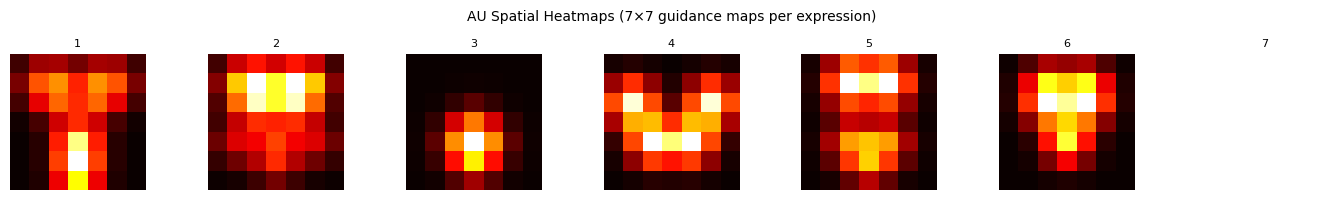

Brighter = ResNet-18 should activate more strongly here.


In [ ]:
# Build AU heatmap table now that we know the dataset class order
# train_dataset.classes = sorted list of class names (alphabetical)
AU_TABLE = build_au_heatmap_table(train_dataset.classes, grid_size=7)
print('AU heatmap table built.')
print(f'  Class order : {train_dataset.classes}')
print(f'  Table shape : {AU_TABLE.shape}  (num_classes, 7, 7)')

# Quick sanity: visualize heatmaps for all 7 expressions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(train_dataset.classes), figsize=(14, 2))
for i, cls in enumerate(train_dataset.classes):
    axes[i].imshow(AU_TABLE[i].cpu().numpy(), cmap='hot', vmin=0, vmax=1)
    axes[i].set_title(cls, fontsize=8)
    axes[i].axis('off')
plt.suptitle('AU Spatial Heatmaps (7×7 guidance maps per expression)', fontsize=10)
plt.tight_layout()
plt.show()
print('Brighter = ResNet-18 should activate more strongly here.')


## 7. CAFE Model Architecture
Exact code from `ours_CAFE.py`

In [ ]:
# ── Custom MaxPool2d (used in channel separation) ────────────────────
class my_MaxPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0, dilation=1,
                 return_indices=False, ceil_mode=False):
        super(my_MaxPool2d, self).__init__()
        self.kernel_size    = kernel_size
        self.stride         = stride or kernel_size
        self.padding        = padding
        self.dilation       = dilation
        self.return_indices = return_indices
        self.ceil_mode      = ceil_mode

    def forward(self, input):
        input = input.transpose(3, 1)
        input = F.max_pool2d(input, self.kernel_size, self.stride,
                             self.padding, self.dilation, self.ceil_mode,
                             self.return_indices)
        input = input.transpose(3, 1).contiguous()
        return input


# ── Channel dropping mask ────────────────────────────────────────────
def Mask(nb_batch):
    """
    Generates random channel drop mask.
    7 expression groups × (63 or 64 channels each) = 512 total
    Drops 10 channels per group randomly.
    """
    bar = []
    for i in range(7):
        foo = [1] * 63 + [0] * 10
        if i == 6:
            foo = [1] * 64 + [0] * 10  # last group gets 1 extra channel
        random.shuffle(foo)
        bar += foo
    bar = [bar for _ in range(nb_batch)]
    bar = np.array(bar).astype('float32')
    bar = bar.reshape(nb_batch, 512, 1, 1)
    bar = torch.from_numpy(bar).to(device)
    bar = Variable(bar)
    return bar


# ── Channel separation + channel diverse loss ────────────────────────
def supervisor(x, targets, cnum=73):
    """
    Computes l_sep (channel separation loss) and l_div (channel diverse loss).

    x       : masked features (N, 512)
    targets : expression labels (N,)
    cnum    : channels per expression group (73 for groups 0-5, 74 for group 6)

    Returns: [l_sep, l_div]
    """
    # l_div — channel diverse loss
    branch = x
    branch = branch.reshape(branch.size(0), branch.size(1), 1, 1)
    branch = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch)
    branch = branch.reshape(branch.size(0), branch.size(1),
                            branch.size(2) * branch.size(3))
    loss_2 = 1.0 - 1.0 * torch.mean(torch.sum(branch, 2)) / cnum

    # l_sep — channel separation cross-entropy loss
    mask    = Mask(x.size(0))
    branch_1 = x.reshape(x.size(0), x.size(1), 1, 1) * mask
    branch_1 = my_MaxPool2d(kernel_size=(1, cnum), stride=(1, cnum))(branch_1)
    branch_1 = branch_1.view(branch_1.size(0), -1)
    loss_1   = nn.CrossEntropyLoss()(branch_1, targets)

    return [loss_1, loss_2]


# ── Custom ResNet-18 BasicBlock ──────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        if downsample:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        i = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        if self.downsample is not None:
            i = self.downsample(i)
        x += i
        return self.relu(x)


# ── Custom ResNet ────────────────────────────────────────────────────
class ResNet(nn.Module):
    def __init__(self, block, n_blocks, channels, output_dim):
        super().__init__()
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4

        self.conv1   = nn.Conv2d(3, self.in_channels, kernel_size=7,
                                  stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(self.in_channels)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2  = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3  = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4  = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(self.in_channels, output_dim)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
        layers = []
        downsample = (self.in_channels != block.expansion * channels)
        layers.append(block(self.in_channels, channels, stride, downsample))
        for _ in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))
        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h


# ── CAFE Main Model ──────────────────────────────────────────────────
class Model(nn.Module):
    """
    CAFE model — exact implementation from ours_CAFE.py

    Forward (train): returns (logits, [l_sep, l_div])
    Forward (test) : returns (logits, logits)

    Loss = l_cls + 1.5 * l_sep + 5 * l_div
    """
    def __init__(self, msceleb_path, num_classes=7, drop_rate=0):
        super(Model, self).__init__()

        # Build ResNet-18 and load MS-Celeb weights
        res18 = ResNet(block=BasicBlock, n_blocks=[2, 2, 2, 2],
                       channels=[64, 128, 256, 512], output_dim=1000)
        msceleb_model = torch.load(msceleb_path, map_location='cpu')
        state_dict    = msceleb_model['state_dict']
        res18.load_state_dict(state_dict, strict=False)
        print('MS-Celeb weights loaded.')

        self.drop_rate = drop_rate
        self.features  = nn.Sequential(*list(res18.children())[:-2])   # conv layers
        self.features2 = nn.Sequential(*list(res18.children())[-2:-1]) # avgpool

        fc_in_dim = list(res18.children())[-1].in_features  # 512
        self.fc   = nn.Linear(fc_in_dim, num_classes)        # 512 → 7

        self.parm = {}
        for name, parameters in self.fc.named_parameters():
            print(name, ':', parameters.size())
            self.parm[name] = parameters

    def forward(self, x, clip_model, targets, phase='train'):
        # CLIP features — frozen, no grad
        with torch.no_grad():
            image_features = clip_model.encode_image(x)
            image_features = image_features.float()  # ensure float32

        # ResNet-18 features
        spatial_map = self.features(x)       # (N, 512, 7, 7)  ← keep for AU loss
        x  = self.features2(spatial_map)     # (N, 512, 1, 1)
        x  = x.view(x.size(0), -1)           # (N, 512)

        # Sigmoid mask + CLIP feature selection
        if phase == 'train':
            MC_loss = supervisor(image_features * torch.sigmoid(x),
                                 targets, cnum=73)
            # Return spatial_map so training loop can compute AU loss
            return image_features * torch.sigmoid(x), self.fc(image_features * torch.sigmoid(x)), MC_loss, spatial_map

        x   = image_features * torch.sigmoid(x)  # (N, 512) masked features
        out = self.fc(x)                           # (N, 7) logits
        return out, out


print('Model architecture defined.')

Model architecture defined.


## 8. Initialize Model, Optimizer, Scheduler

In [ ]:
setup_seed(3407)

model = Model(msceleb_path=MSCELEB_PATH, num_classes=NUM_CLASSES)
model.to(device)

# From original CAFE code
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

EPOCHS = 20

print(f'\nOptimizer : Adam  lr=0.0002, wd=1e-4')
print(f'Scheduler : ExponentialLR gamma=0.9')
print(f'Epochs    : {EPOCHS}')

MS-Celeb weights loaded.
weight : torch.Size([7, 512])
bias : torch.Size([7])

Optimizer : Adam  lr=0.0002, wd=1e-4
Scheduler : ExponentialLR gamma=0.9
Epochs    : 20


## 9. Train and Test Functions

In [ ]:
######## IMPROVISATION | CLASS IMBALANCE PUNISHMENT ##################
from collections import Counter

# Fast version — reads labels directly, no image loading
label_counts = Counter(train_dataset.labels)
class_counts = torch.tensor([label_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)

print("Samples per class:")
for i, cls in enumerate(train_dataset.classes):
    print(f"  {cls}: {int(class_counts[i])}")

# Weight = total / (num_classes * class_count)
# Minority → higher weight, Majority → lower weight
total = class_counts.sum()
class_weights = total / (NUM_CLASSES * class_counts)
class_weights = torch.clamp(class_weights, max=3.0)  # prevent extreme weights
class_weights = class_weights.to(device)

print(f"\nClass weights: {class_weights.tolist()}")

Samples per class:
  1: 1290
  2: 281
  3: 717
  4: 4772
  5: 1982
  6: 705
  7: 2524

Class weights: [1.3589147329330444, 6.238434314727783, 2.4449093341827393, 0.3673512041568756, 0.8844601511955261, 2.486524820327759, 0.6945325136184692]


In [ ]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device, au_table):
    """
    One training epoch.
    loss = l_cls + 1.5*l_sep + 5*l_div + 0.5*l_AU

    l_AU is our AU spatial alignment improvement:
    it encourages ResNet-18's layer4 spatial activations to align
    with the AU guidance heatmap for each sample's expression.
    """
    model.train()
    running_loss = 0.0
    iter_cnt     = 0
    correct_sum  = 0

    for imgs, labels, indexes, imgs_flip in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        # Forward — now returns (masked_features, logits, MC_loss, spatial_map)
        _, output, MC_loss, spatial_map = model(imgs, clip_model, labels, phase='train')

        # l_cls — standard classification loss
        #loss_cls = nn.CrossEntropyLoss()(output, labels)

        # l_cls after class imbalance
        loss_cls = nn.CrossEntropyLoss(weight=class_weights)(output, labels)

        # l_AU — spatial AU alignment loss (our improvement)
        loss_au = au_alignment_loss(spatial_map, labels, au_table)

        # Total loss
        loss = loss_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0] + 0.5 * loss_au

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iter_cnt += 1
        _, predicts  = torch.max(output, 1)
        correct_sum  += torch.eq(predicts, labels).sum()
        running_loss += loss

    scheduler.step()
    running_loss = running_loss / iter_cnt
    acc = correct_sum.float() / float(train_loader.dataset.__len__())
    return acc.item(), running_loss.item()


def test_model(model, test_loader, device):
    """
    Evaluation — no AU loss at test time (same as original CAFE).
    """
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        iter_cnt     = 0
        correct_sum  = 0
        data_num     = 0

        for imgs, labels, indexes, imgs_flip in test_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs, _ = model(imgs, clip_model, labels, phase='test')
            loss       = nn.CrossEntropyLoss()(outputs, labels)

            iter_cnt  += 1
            _, predicts = torch.max(outputs, 1)
            correct_sum += torch.eq(predicts, labels).sum()
            running_loss += loss
            data_num     += outputs.size(0)

        running_loss = running_loss / iter_cnt
        test_acc     = correct_sum.float() / float(data_num)

    return test_acc.item(), running_loss.item()


print('Train and test functions ready.')
print('Training loss = l_cls + 1.5×l_sep + 5×l_div + 0.5×l_AU')


Train and test functions ready.
Training loss = l_cls + 1.5×l_sep + 5×l_div + 0.5×l_AU


In [ ]:
# Check GPU
!nvidia-smi

# Check batch size and how many batches per epoch
print(f'Batch size     : {BATCH_SIZE}')
print(f'Train batches  : {len(train_loader)}')
print(f'Estimated time : {len(train_loader) * 3} seconds per epoch')

Wed Apr 29 21:16:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             31W /   70W |     515MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 10. Training Loop

In [ ]:
history = {'train_acc': [], 'train_loss': [], 'test_acc': [], 'test_loss': []}
best_acc = 0.0

print('=' * 60)
print(f'Training CAFE on {DATASET_NAME}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):

    train_acc, train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, device, AU_TABLE
    )
    test_acc, test_loss = test_model(model, test_loader, device)

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['test_acc'].append(test_acc)
    history['test_loss'].append(test_loss)

    print(f'Epoch [{epoch:>3}/{EPOCHS}] '
          f'Train Acc: {train_acc*100:5.2f}% Loss: {train_loss:.4f} | '
          f'Test Acc: {test_acc*100:5.2f}% Loss: {test_loss:.4f}')

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({'model_state_dict': model.state_dict()}, 'ours_best.pth')
        print(f'  ✓ Best model saved (acc={best_acc*100:.2f}%)')

    # Save latest
    torch.save({'model_state_dict': model.state_dict()}, 'ours_final.pth')

    # Log to file
    with open('results.txt', 'a') as f:
        f.write(f'{epoch}_{test_acc:.4f}\n')

print('=' * 60)
print(f'Training complete. Best test acc: {best_acc*100:.2f}%')

Training CAFE on RAFDB
Epoch [  1/20] Train Acc: 50.89% Loss: 9.6657 | Test Acc: 68.25% Loss: 1.5373
  ✓ Best model saved (acc=68.25%)
Epoch [  2/20] Train Acc: 73.13% Loss: 9.1920 | Test Acc: 75.29% Loss: 1.2554
  ✓ Best model saved (acc=75.29%)
Epoch [  3/20] Train Acc: 77.62% Loss: 8.9143 | Test Acc: 79.73% Loss: 1.0610
  ✓ Best model saved (acc=79.73%)
Epoch [  4/20] Train Acc: 80.68% Loss: 8.7280 | Test Acc: 81.00% Loss: 0.9347
  ✓ Best model saved (acc=81.00%)
Epoch [  5/20] Train Acc: 83.91% Loss: 8.5673 | Test Acc: 83.15% Loss: 0.8327
  ✓ Best model saved (acc=83.15%)
Epoch [  6/20] Train Acc: 85.85% Loss: 8.4533 | Test Acc: 83.83% Loss: 0.7521
  ✓ Best model saved (acc=83.83%)
Epoch [  7/20] Train Acc: 87.99% Loss: 8.3477 | Test Acc: 84.97% Loss: 0.7107
  ✓ Best model saved (acc=84.97%)
Epoch [  8/20] Train Acc: 89.80% Loss: 8.2470 | Test Acc: 85.01% Loss: 0.6723
  ✓ Best model saved (acc=85.01%)
Epoch [  9/20] Train Acc: 91.01% Loss: 8.1877 | Test Acc: 86.73% Loss: 0.6360
  ✓

## 11. Training Curves

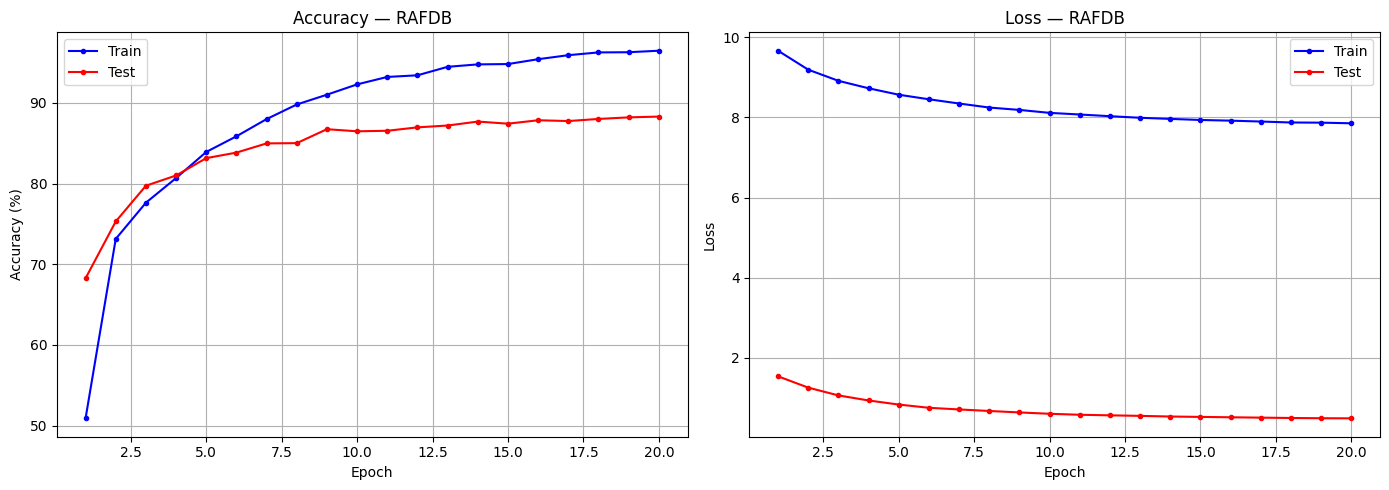

Best test accuracy: 88.30%


In [ ]:
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(history['train_acc']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_x, [a * 100 for a in history['train_acc']], 'b-o',
             markersize=3, label='Train')
axes[0].plot(epochs_x, [a * 100 for a in history['test_acc']],  'r-o',
             markersize=3, label='Test')
axes[0].set_title(f'Accuracy — {DATASET_NAME}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_x, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[1].plot(epochs_x, history['test_loss'],  'r-o', markersize=3, label='Test')
axes[1].set_title(f'Loss — {DATASET_NAME}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('cafe_training_curves.png', dpi=150)
plt.show()
print(f'Best test accuracy: {best_acc * 100:.2f}%')

## 12. Load Best Model and Run Final Evaluation

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load('ours_best.pth', map_location=device)['model_state_dict'])
print('Best model loaded.')

final_acc, final_loss = test_model(model, test_loader, device)
print(f'Final Test Accuracy : {final_acc * 100:.2f}%')
print(f'Final Test Loss     : {final_loss:.4f}')

Best model loaded.
Final Test Accuracy : 88.30%
Final Test Loss     : 0.4887


## 13. Per-Class Accuracy

In [ ]:
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for imgs, labels, _, _ in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs, _   = model(imgs, clip_model, labels, phase='test')
        _, predicts  = torch.max(outputs, 1)
        for t, p in zip(labels, predicts):
            class_correct[t.item()] += (t == p).item()
            class_total[t.item()]   += 1

print('Per-class accuracy:')
print('-' * 30)
for i, cls in enumerate(train_dataset.classes):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f'  {cls:<12} : {acc:5.2f}%  ({class_correct[i]}/{class_total[i]})')
print('-' * 30)
print(f'  {"Mean":<12} : {final_acc*100:.2f}%')

Per-class accuracy:
------------------------------
  1            : 85.41%  (281/329)
  2            : 59.46%  (44/74)
  3            : 67.50%  (108/160)
  4            : 94.51%  (1120/1185)
  5            : 87.24%  (417/478)
  6            : 78.40%  (127/162)
  7            : 90.00%  (612/680)
------------------------------
  Mean         : 88.30%


## 14. Sanity Check (No Data Needed)
Run this cell first to verify model forward pass works correctly.

In [ ]:
print('Running sanity check...')
model.eval()

dummy_imgs   = torch.randn(4, 3, 224, 224).to(device)
dummy_labels = torch.randint(0, 7, (4,)).to(device)

# Test phase
with torch.no_grad():
    out, _ = model(dummy_imgs, clip_model, dummy_labels, phase='test')
print(f'Output shape (test) : {out.shape}  (expected: [4, 7])')

# Train phase
model.train()
_, out, MC_loss, spatial_map = model(dummy_imgs, clip_model, dummy_labels, phase='train')
l_cls = nn.CrossEntropyLoss()(out, dummy_labels)
l_au  = au_alignment_loss(spatial_map, dummy_labels, AU_TABLE)
total = l_cls + 5 * MC_loss[1] + 1.5 * MC_loss[0] + 0.5 * l_au

print(f'Output shape (train): {out.shape}  (expected: [4, 7])')
print(f'Spatial map shape   : {spatial_map.shape}  (expected: [4, 512, 7, 7])')
print(f'l_cls  : {l_cls.item():.4f}')
print(f'l_sep  : {MC_loss[0].item():.4f}')
print(f'l_div  : {MC_loss[1].item():.4f}')
print(f'l_AU   : {l_au.item():.4f}  ← our AU alignment loss')
print(f'total  : {total.item():.4f}')
print('\nSanity check passed! ✓')


Running sanity check...
Output shape (test) : torch.Size([4, 7])  (expected: [4, 7])
Output shape (train): torch.Size([4, 7])  (expected: [4, 7])
Spatial map shape   : torch.Size([4, 512, 7, 7])  (expected: [4, 512, 7, 7])
l_cls  : 2.3747
l_sep  : 1.9571
l_div  : 0.9918
l_AU   : 0.1607  ← our AU alignment loss
total  : 10.3498

Sanity check passed! ✓
